In [41]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from scipy.ndimage import label
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [42]:
import random as rng

def get_gaussian(mu,sigma):
    def gaussian(x):
        a = -1/2 * (x-mu)**2/sigma**2
        return np.exp(a)/(sigma*np.sqrt(2*np.pi))
    return np.vectorize(gaussian)
def get_ReLU(freq):
    def ReLU(x):
        return abs((x) * (x > 1-freq))
    return ReLU

class simulacra_dataset(Dataset):
    """simulacra of simulated data of neutrinos dataset."""

    def __init__(self, min_val, max_val, target_snr, length, seed, pusle_length):
        """
        Arguments:
            csv_file (string): Path to the csv file with annotations.
            root_dir (string): Directory with all the images.
            transform (callable, optional): Optional transform to be applied
                on a sample.
        """
        self.min_val = min_val
        self.max_val = max_val
        self.target_snr = target_snr
        self.length = length
        self.seed = seed
        self.pusle_length = pusle_length

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        np.random.seed(idx+self.seed)
        relu1 = get_ReLU(0.2)
        relu2 = get_ReLU(0.3)
        mu1 = rng.randint(self.min_val,self.max_val)
        sigma1 = rng.randint(10,30)
        mu2 = rng.randint(self.min_val,self.max_val)
        sigma2 = rng.randint(10,30)
        weight1 = relu1(rng.random())
        weight2 = relu2(rng.random())
        pulse = [get_gaussian(mu1,sigma1),get_gaussian(mu1+sigma1,sigma1),get_gaussian(mu2,sigma2)]

        mu, sigma = 0, 0.1 # mean and standard deviation
        s = np.random.normal(mu, sigma, self.pusle_length)
        a = np.linspace(0,self.pusle_length,self.pusle_length)
        wave = pulse[0](a) - pulse[1](a)*weight1 + pulse[2](a)*weight2
        snr = max(wave)/max(s)
        weight = target_snr/snr
        res = wave*weight + s
        return {
            "x": torch.from_numpy(res).float().unsqueeze(0),
            "y": torch.from_numpy(wave*weight).float().unsqueeze(0),
        }

min_val, max_val, target_snr, length, seed, pusle_length = 20,500,100,100,0,512
train_ds = simulacra_dataset(min_val, max_val, target_snr, length, seed, pusle_length)
length, seed = 100,1000
val_ds = simulacra_dataset(min_val, max_val, target_snr, length, seed, pusle_length)
length, seed = 100,2000
test_ds = simulacra_dataset(min_val, max_val, target_snr, length, seed, pusle_length)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

batch = next(iter(train_loader))
batch["x"].shape, batch["y"].shape

(torch.Size([64, 1, 512]), torch.Size([64, 1, 512]))

In [43]:
import torch
import torch.fft as Tfft
import torch.nn as nn

class SimpleFourier(nn.Module):
    def __init__(self, input_size: int):
        super().__init__()
        self.input_size = input_size
        fft_out_size = input_size // 2 + 1 

        self.activation = nn.Tanh()

        self.fc_real = nn.Sequential(
            nn.Linear(in_features=fft_out_size, out_features=fft_out_size*2),
            nn.Linear(in_features=fft_out_size*2, out_features=fft_out_size),
        )
        self.fc_imag = nn.Sequential(
            nn.Linear(in_features=fft_out_size, out_features=fft_out_size*2),
            nn.Linear(in_features=fft_out_size*2, out_features=fft_out_size),
        )

    def forward(self, x):
        x = Tfft.rfft(x)

        real = self.fc_real(x.real)
        imag = self.fc_imag(x.imag)

        real = self.activation(real)
        imag = self.activation(imag)

        x = torch.complex(real, imag)
        x = Tfft.irfft(x, n=self.input_size) 
        return x

In [44]:
model = SimpleFourier(
    input_size=pusle_length
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-4,
    weight_decay=1e-4,
)

model

SimpleFourier(
  (activation): Tanh()
  (fc_real): Sequential(
    (0): Linear(in_features=257, out_features=514, bias=True)
    (1): Linear(in_features=514, out_features=257, bias=True)
  )
  (fc_imag): Sequential(
    (0): Linear(in_features=257, out_features=514, bias=True)
    (1): Linear(in_features=514, out_features=257, bias=True)
  )
)

In [45]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-2,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=10,
    min_lr=1e-6,
)

In [46]:
def run_epoch(loader, train=True, max_grad_norm=1.0):
    model.train() if train else model.eval()

    total_loss = 0.0
    skipped = 0

    for batch in loader:
        x = batch["x"].to(device)
        y = batch["y"].to(device)

        with torch.set_grad_enabled(train):
            y_hat = model(x)

            loss = F.smooth_l1_loss(y_hat, y)

            if not torch.isfinite(loss):
                skipped += 1
                continue

            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=max_grad_norm,
                )

                optimizer.step()

        total_loss += loss.item()

    n = max(1, len(loader) - skipped)

    return {
        "loss": total_loss / n,
        "skipped": skipped,
    }

In [47]:
num_epochs = 100

history = {
    "train_loss": [],
    "val_loss": [],
    "lr": [],
}

best_val = float("inf")
best_state = None
patience = 20
bad_epochs = 0

for epoch in range(1, num_epochs + 1):

    train_stats = run_epoch(
        train_loader,
        train=True,
        max_grad_norm=1.0,
    )

    val_stats = run_epoch(
        val_loader,
        train=False,
        max_grad_norm=1.0,
    )

    scheduler.step(val_stats["loss"])

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_stats["loss"])
    history["val_loss"].append(val_stats["loss"])
    history["lr"].append(current_lr)

    if val_stats["loss"] < best_val:
        best_val = val_stats["loss"]
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }
        bad_epochs = 0
    else:
        bad_epochs += 1

    print(
        f"Epoch {epoch:03d} | "
        f"lr {current_lr:.2e} | "
        f"train {train_stats['loss']:.6f} | "
        f"val {val_stats['loss']:.6f} | "
        f"skipped {train_stats['skipped']}"
    )

    if bad_epochs >= patience:
        print("Early stopping.")
        break

model.load_state_dict(best_state)
model.to(device)

Epoch 001 | lr 1.00e-02 | train 3.663931 | val 3.224375 | skipped 0
Epoch 002 | lr 1.00e-02 | train 3.407035 | val 3.326547 | skipped 0
Epoch 003 | lr 1.00e-02 | train 3.522472 | val 3.324916 | skipped 0
Epoch 004 | lr 1.00e-02 | train 3.414393 | val 3.366341 | skipped 0
Epoch 005 | lr 1.00e-02 | train 3.639695 | val 3.609838 | skipped 0
Epoch 006 | lr 1.00e-02 | train 3.442351 | val 3.614784 | skipped 0
Epoch 007 | lr 1.00e-02 | train 3.416809 | val 3.232633 | skipped 0
Epoch 008 | lr 1.00e-02 | train 3.198596 | val 3.420827 | skipped 0
Epoch 009 | lr 1.00e-02 | train 3.508973 | val 3.498024 | skipped 0
Epoch 010 | lr 1.00e-02 | train 3.590655 | val 3.303519 | skipped 0
Epoch 011 | lr 1.00e-02 | train 3.274936 | val 3.360056 | skipped 0
Epoch 012 | lr 5.00e-03 | train 3.314948 | val 3.438181 | skipped 0
Epoch 013 | lr 5.00e-03 | train 3.473472 | val 3.441759 | skipped 0
Epoch 014 | lr 5.00e-03 | train 3.258853 | val 3.184572 | skipped 0
Epoch 015 | lr 5.00e-03 | train 3.480903 | val 3

SimpleFourier(
  (activation): Tanh()
  (fc_real): Sequential(
    (0): Linear(in_features=257, out_features=514, bias=True)
    (1): Linear(in_features=514, out_features=257, bias=True)
  )
  (fc_imag): Sequential(
    (0): Linear(in_features=257, out_features=514, bias=True)
    (1): Linear(in_features=514, out_features=257, bias=True)
  )
)

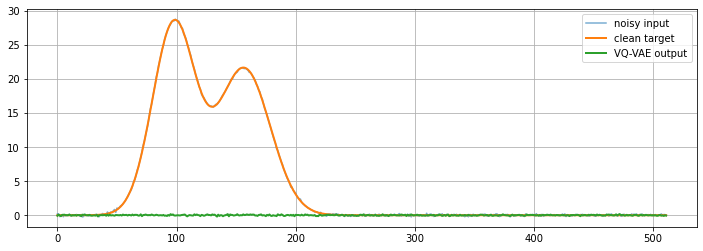

In [48]:
model.eval()

batch = next(iter(test_loader))

x = batch["x"].to(device)
y = batch["y"].to(device)

with torch.no_grad():
    y_hat = model(x)

idx = 0

noisy = x[idx, 0].cpu().numpy()
clean = y[idx, 0].cpu().numpy()
pred = y_hat[idx, 0].cpu().numpy()

plt.figure(figsize=(12, 4))
plt.plot(noisy, label="noisy input", alpha=0.6)
plt.plot(clean, label="clean target", linewidth=2)
plt.plot(pred, label="VQ-VAE output", linewidth=2)
plt.legend()
plt.grid(True)
plt.show()